### Weights & Biases Setup
This section installs the `wandb` library and logs into your Weights & Biases account. It attempts a non-interactive login using the `WANDB_API_KEY` stored in Colab secrets. If the key is not found, it will attempt an interactive login.

In [2]:
# Install wandb library
!pip install wandb -qqq

# import colab user data
from google.colab import userdata
import wandb

# Log in to wandb non-interactively using the API key from Colab secrets
wandb_api_key = userdata.get('WANDB_API_KEY')
if wandb_api_key:
  print("WANDB_API_KEY found. Attempting non-interactive login to Weights & Biases.")
  wandb.login(key=wandb_api_key)
else:
  print("WANDB_API_KEY not found in environment variables. Attempting interactive login.")
  print("Please ensure your W&B API key is set as a secret named 'WANDB_API_KEY' in Colab or your environment.")
  wandb.login()

WANDB_API_KEY found. Attempting non-interactive login to Weights & Biases.


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gbera23 (gbera23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### GitHub Repository Cloning
This section clones the specified GitHub repository. It attempts to use a GitHub Personal Access Token (`GITHUB_TOKEN`) stored in Colab secrets for private repositories. If no token is found, it will attempt to clone the repository directly, which will only succeed for public repositories or if credentials are otherwise configured.

In [63]:
import os

# GitHub repository cloning
# If the repository is private, a Personal Access Token (PAT) is required.
# Assuming 'github' (which is the GITHUB_TOKEN) is available as a secret.
github_token = userdata.get('github')
repo_url = "https://github.com/gbera23-dev/Machine-Learning.git"

if github_token:
  print("GITHUB_TOKEN found. Attempting to clone GitHub repository using token.")
  # Embed the token in the URL for cloning private repos
  !git clone https://{github_token}@github.com/gbera23-dev/Machine-Learning.git
else:
  print("GITHUB_TOKEN not found in environment variables. Attempting to clone repository without explicit token.")
  print("If the repository is private, please ensure your GitHub Personal Access Token is set as a secret named 'github' in Colab or your environment.")
  !git clone {repo_url}

# Verify the repository was cloned
if os.path.exists("Machine-Learning"):
    print("Repository 'Machine-Learning' cloned successfully.")
else:
    print("Failed to clone repository 'Machine-Learning'. Please check your GitHub token if it's a private repo.")

GITHUB_TOKEN found. Attempting to clone GitHub repository using token.
Cloning into 'Machine-Learning'...
remote: Enumerating objects: 163, done.
remote: Counting objects: 100% (163/163), done.
remote: Compressing objects: 100% (124/124), done.
remote: Total 163 (delta 71), reused 113 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (163/163), 924.97 KiB | 16.52 MiB/s, done.
Resolving deltas: 100% (71/71), done.
Repository 'Machine-Learning' cloned successfully.


In [4]:
# Install the Kaggle API client
!pip install kaggle -qqq

### Kaggle authorization

In [13]:
%cd Assignment4

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

[Errno 2] No such file or directory: 'Assignment4'
/content/Machine-Learning/Assignment4


### Download Kaggle Competition Data

Now, we can download the data for the 'Challenges in Representation Learning, Facial Expression Recognition Challenge' competition. The competition name on Kaggle is `challenges-in-representation-learning-facial-expression-recognition-challenge`.

In [14]:
# Define the competition name
competition_name = 'challenges-in-representation-learning-facial-expression-recognition-challenge'

# Download the competition data
!kaggle competitions download -c {competition_name}

100% 285M/285M [00:01<00:00, 178MB/s]



### Unzip the Downloaded Data

In [15]:
zip_file_name = f"{competition_name}.zip"

!unzip -q {zip_file_name} -d "./{competition_name}_data"

!ls -F "./{competition_name}_data"

print(f"Data unzipped to ./{competition_name}_data")

example_submission.csv	fer2013.tar.gz	icml_face_data.csv  test.csv  train.csv
Data unzipped to ./challenges-in-representation-learning-facial-expression-recognition-challenge_data


### Change directory to Machine-Learning

In [16]:
# %cd Machine-Learning

[Errno 2] No such file or directory: 'Machine-Learning'
/content/Machine-Learning/Assignment4


## 1. Exploratory Data Analysis (EDA)
We will load the dataset and visualize the classes to understand the distribution of emotions.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Path to the data
data_path = './challenges-in-representation-learning-facial-expression-recognition-challenge_data/icml_face_data.csv'
df = pd.read_csv(data_path)

# Display basic info
print(f"Dataset Shape: {df.shape}")
display(df.head())

# Check the usage split (Training, PublicTest, PrivateTest)
print("\nUsage distribution:")
print(df[' Usage'].value_counts())

Dataset Shape: (35887, 3)


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...
3,4,Training,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...
4,6,Training,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...



Usage distribution:
 Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


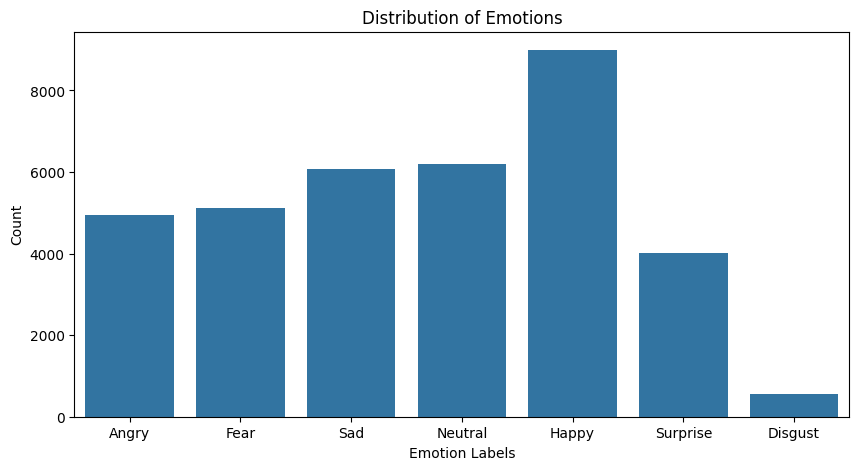

In [18]:
# Emotion mapping
emotion_map = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Visualize Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=df['emotion'].map(emotion_map))
plt.title('Distribution of Emotions')
plt.xlabel('Emotion Labels')
plt.ylabel('Count')
plt.show()

Sample images from the dataset:


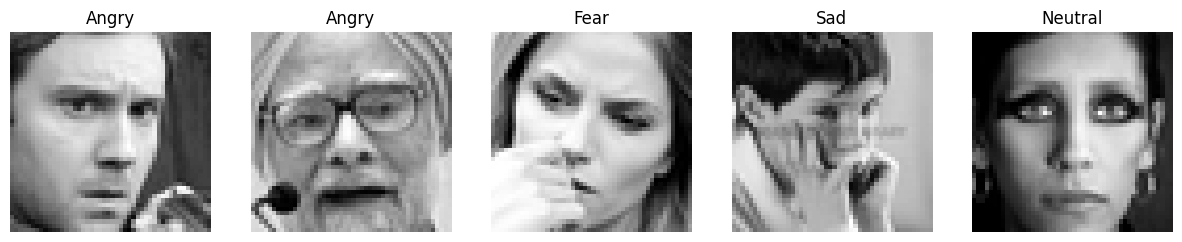

In [19]:
def plot_samples(df, num_samples=5):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):

        pixels = df.iloc[i][' pixels'].split()
        image = np.array(pixels, dtype='float32').reshape(48, 48)

        plt.subplot(1, num_samples, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(emotion_map[df.iloc[i]['emotion']])
        plt.axis('off')
    plt.show()

print("Sample images from the dataset:")
plot_samples(df)

### 1.2 Deep Dive into Data Structure
Let's look at the raw training data structure and the distribution of pixel intensities across all images.

Raw Pixel Data Example (First 50 characters of the first row):
70 80 82 72 58 58 60 63 54 58 60 48 89 115 121 119...


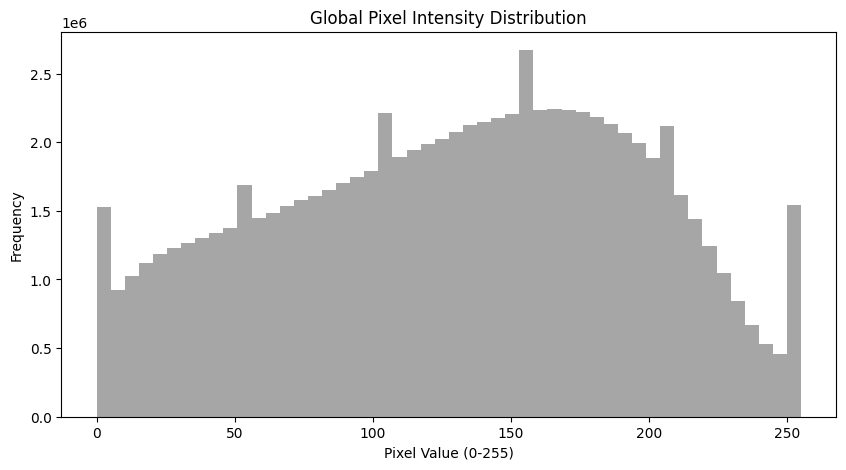

In [20]:
print("Raw Pixel Data Example (First 50 characters of the first row):")
print(df.loc[0, ' pixels'][:50] + "...")

all_pixels = np.array([np.fromstring(x, dtype=int, sep=' ') for x in df[' pixels']])

plt.figure(figsize=(10, 5))
plt.hist(all_pixels.flatten(), bins=50, color='gray', alpha=0.7)

plt.title('Global Pixel Intensity Distribution')
plt.xlabel('Pixel Value (0-255)')
plt.ylabel('Frequency')
plt.show()

### 1.3 How do we distinguish emotions?

---



---


By calculating the **Average (Mean) Image** for each emotion, we can see the 'template' features the model might look for (e.g., teeth in 'Happy', wider eyes in 'Surprise').

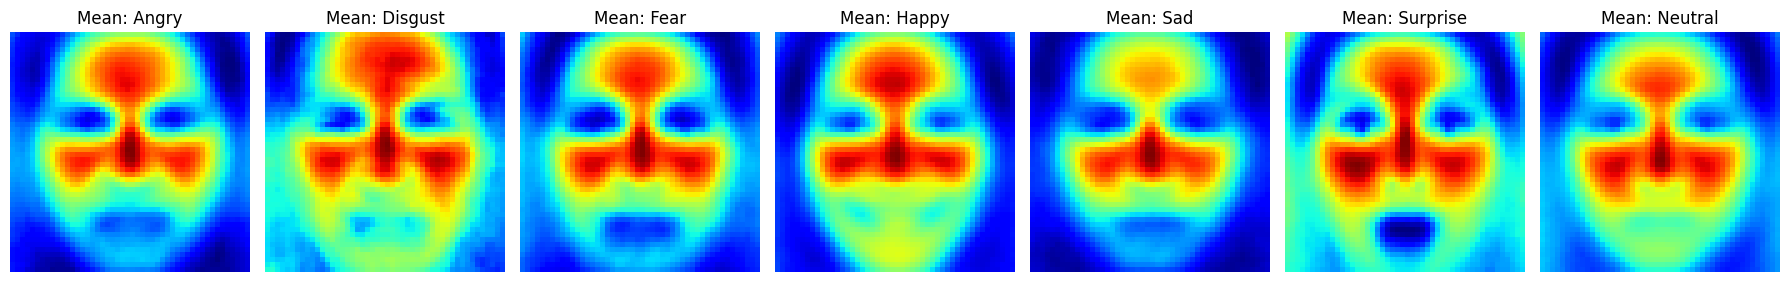

In [21]:
plt.figure(figsize=(18, 10))

for emotion_idx, name in emotion_map.items():
    idx = df[df['emotion'] == emotion_idx].index
    emotion_pixels = all_pixels[idx]

    mean_img = np.mean(emotion_pixels, axis=0).reshape(48, 48)

    plt.subplot(1, 7, emotion_idx + 1)
    plt.imshow(mean_img, cmap='jet')
    plt.title(f"Mean: {name}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 2. Data Preparation
We will create a custom PyTorch Dataset to handle the conversion of pixel strings to tensors and apply basic normalization.

In [22]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Extract pixels and label
        pixels = self.df.iloc[idx][' pixels'].split()
        image = np.array(pixels, dtype='float32').reshape(48, 48)
        label = int(self.df.iloc[idx]['emotion'])

        # Add channel dimension (H, W) -> (H, W, C) for transforms
        image = image[:, :, np.newaxis] / 255.0

        if self.transform:
            image = self.transform(image)

        return image, label

# Define basic transforms
train_transform = transforms.Compose([
    transforms.ToTensor(),
    # Note: We can add augmentation here later
    transforms.Normalize((0.5,), (0.5,))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Split the dataframe based on ' Usage'
train_df = df[df[' Usage'] == 'Training']
val_df = df[df[' Usage'] == 'PublicTest']

# Initialize Datasets
train_dataset = FERDataset(train_df, transform=train_transform)
val_dataset = FERDataset(val_df, transform=val_transform)

# Create Dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"DataLoaders created with {len(train_dataset)} training and {len(val_dataset)} validation samples.")

DataLoaders created with 28709 training and 3589 validation samples.


## 3. Model Development
### 3.1 Baseline CNN
We define a simple CNN architecture to start our experiments.

In [23]:
import torch.nn as nn
import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(BaselineCNN, self).__init__()
        # Convolutional Layer 1: 1 input channel (grayscale), 32 filters, 3x3 kernel
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # Convolutional Layer 2: 32 input, 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # After two 2x2 pools, 48x48 becomes 12x12
        self.fc1 = nn.Linear(64 * 12 * 12, 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = x.view(-1, 64 * 12 * 12)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BaselineCNN(num_classes=7).to(device)

print(f"Model initialized on device: {device}")

Model initialized on device: cuda


### 3.2 Define Loss Function and Optimizer
We will use CrossEntropyLoss (standard for classification) and the Adam optimizer.

In [24]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer defined.")

Loss function and optimizer defined.


### 3.3 Unified Pipeline & W&B Experiment Setup
We wrap the model and preprocessing into a single class and initialize a W&B run to track our experiment.

In [25]:
import wandb

class FERPipeline(nn.Module):
    """Unified pipeline for preprocessing and inference."""
    def __init__(self, model, transform):
        super(FERPipeline, self).__init__()
        self.model = model
        self.transform = transform

    def forward(self, x):
        # Assuming x is a batch of images already converted to tensors
        return self.model(x)

    def predict_raw(self, pixel_string):
        """Helper for single string inference"""
        self.model.eval()
        with torch.no_grad():
            pixels = np.array(pixel_string.split(), dtype='float32').reshape(48, 48)
            image = pixels[:, :, np.newaxis] / 255.0
            tensor = self.transform(image).unsqueeze(0).to(device)
            output = self.model(tensor)
            return torch.softmax(output, dim=1)

# Initialize the pipeline
fer_pipeline = FERPipeline(model, val_transform)

# Initialize W&B Run
wandb.init(
    project="facial-expression-recognition",
    name="baseline-cnn-v1",
    config={
        "learning_rate": 0.001,
        "architecture": "BaselineCNN",
        "dataset": "FER2013",
        "epochs": 10,
        "batch_size": 64
    }
)

print("Pipeline initialized and W&B experiment started.")

Pipeline initialized and W&B experiment started.


### 3.4 Training Loop
We iterate through the training data, update the model weights, and log metrics to W&B.

In [26]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    avg_train_loss = running_loss / len(train_loader)

    # Log to W&B
    wandb.log({"epoch": epoch + 1, "train_loss": avg_train_loss, "val_accuracy": val_acc})
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_train_loss:.4f}, Val Acc: {val_acc:.2f}%")

print("Finished Training")

Epoch [1/10], Loss: 1.6028, Val Acc: 45.39%
Epoch [2/10], Loss: 1.4022, Val Acc: 47.48%
Epoch [3/10], Loss: 1.2942, Val Acc: 50.29%
Epoch [4/10], Loss: 1.2101, Val Acc: 51.60%
Epoch [5/10], Loss: 1.1284, Val Acc: 52.38%
Epoch [6/10], Loss: 1.0492, Val Acc: 52.91%
Epoch [7/10], Loss: 0.9692, Val Acc: 53.89%
Epoch [8/10], Loss: 0.8911, Val Acc: 53.83%
Epoch [9/10], Loss: 0.8109, Val Acc: 53.64%
Epoch [10/10], Loss: 0.7352, Val Acc: 53.30%
Finished Training


### 3.5 Save Model
We save the pipeline state for future use and finish the W&B run.

In [27]:
# Save the model and pipeline
torch.save(fer_pipeline.state_dict(), 'baseline_cnn_pipeline.pth')
wandb.save('baseline_cnn_pipeline.pth')

# Finish W&B session
wandb.finish()
print("Model saved and W&B run completed.")

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


epoch,▁▂▃▃▄▅▆▆▇█
train_loss,█▆▆▅▄▄▃▂▂▁
val_accuracy,▁▃▅▆▇▇████
epoch,10
train_loss,0.73523
val_accuracy,53.30176


Model saved and W&B run completed.
